# 09 — Baseline Model Comparison

Two-part comparison using the NB08-selected feature set:

1. **Horizon comparison** — which prediction target gives the best signal? (1h / 4h / 24h downside)
2. **Algorithm comparison** — which model performs best on the winning horizon? (LR / RF / LightGBM / XGBoost / CatBoost)

All models use **default hyperparameters** — tuning is reserved for NB22.  
Note: no 12h label exists in the parquet; closest available horizons are 4h and 24h.

| Split | Period |
|---|---|
| Train | Aug 2017 → Jan 2022 |
| Embargo | Jan 2022 (1 month) |
| Val (within train) | Jan 2021 → Jan 2022 |
| Test | Feb 2022 → Feb 2026 |

Primary metric: **PR-AUC Lift** (PR-AUC / base rate) — scale-free, robust to class imbalance.

In [1]:
import os, sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm not installed")

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed")

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False
    print("catboost not installed")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"LightGBM: {HAS_LGB}  XGBoost: {HAS_XGB}  CatBoost: {HAS_CAT}")

LightGBM: True  XGBoost: True  CatBoost: True


In [2]:
DRIVE_PROJECT_PATH = 'MyDrive/Capstone'
LOCAL_PROJECT_PATH = None

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive') / DRIVE_PROJECT_PATH
elif LOCAL_PROJECT_PATH is not None:
    ROOT = Path(LOCAL_PROJECT_PATH)
else:
    _cands = [Path.cwd()] + list(Path.cwd().parents)
    ROOT = next((p for p in _cands if (p / 'config' / 'settings.py').exists()), None)
    if ROOT is None:
        raise FileNotFoundError('Cannot find project root')

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
FEATURES_DIR = ROOT / 'data' / 'processed' / 'features'
print(f'Root: {ROOT}')

Root: /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global


In [3]:
# ── Splits (aligned with NB22)
TRAIN_END   = pd.Timestamp('2022-01-01', tz='UTC')
EMBARGO_END = pd.Timestamp('2022-02-01', tz='UTC')
VAL_START   = pd.Timestamp('2021-01-01', tz='UTC')

# ── Horizons to compare (no 12h label in parquet)
TARGETS = [
    'depeg_next_1h_down',
    'depeg_next_4h_down',
    'depeg_next_24h_down',
]

LABEL_COLS = [
    'depeg', 'depeg_down',
    'depeg_next_5min',  'depeg_next_5min_down',
    'depeg_next_30min', 'depeg_next_30min_down',
    'depeg_next_1h',    'depeg_next_1h_down',
    'depeg_next_4h',    'depeg_next_4h_down',
    'depeg_next_24h',   'depeg_next_24h_down',
]
META_COLS = ['coin_key', 'coin', 'date', 'time', 'peg', 'coin_type', 'coin_status']

# ── Features from NB08 pipeline
with open(FEATURES_DIR / 'selected_features.json') as f:
    _sel = json.load(f)
FEATURES = _sel['selected_features']

print(f'Loaded {len(FEATURES)} features from selected_features.json')
print(f'Targets: {TARGETS}')
print(f'Train: up to {TRAIN_END.date()}  |  Embargo through {EMBARGO_END.date()}  |  Val from {VAL_START.date()}')

Loaded 40 features from selected_features.json
Targets: ['depeg_next_1h_down', 'depeg_next_4h_down', 'depeg_next_24h_down']
Train: up to 2022-01-01  |  Embargo through 2022-02-01  |  Val from 2021-01-01


In [4]:
df = pd.read_parquet(FEATURES_DIR / 'pooled_5m.parquet')
df.index = pd.to_datetime(df.index, utc=True)
for col in LABEL_COLS:
    if col in df.columns and df[col].dtype.name == 'Int8':
        df[col] = df[col].astype(float)

df_stable = df[df['depeg'] == 0].dropna(subset=TARGETS)
FEATURES = [f for f in FEATURES if f in df_stable.columns]

tr  = df_stable[df_stable.index <  TRAIN_END]
val = df_stable[(df_stable.index >= VAL_START) & (df_stable.index < TRAIN_END)]
te  = df_stable[df_stable.index >= EMBARGO_END]

imp = SimpleImputer(strategy='constant', fill_value=0.0)
X_tr  = imp.fit_transform(tr[FEATURES].values)
X_val = imp.transform(val[FEATURES].values)
X_te  = imp.transform(te[FEATURES].values)

print(f'Train: {len(tr):,}  Val: {len(val):,}  Test: {len(te):,}  Features: {len(FEATURES)}')
for t in TARGETS:
    print(f'  {t:<28}: train={tr[t].mean():.3%}  val={val[t].mean():.3%}  test={te[t].mean():.3%}')

Train: 1,325,907  Val: 518,568  Test: 1,729,161  Features: 40
  depeg_next_1h_down          : train=0.422%  val=0.069%  test=0.017%
  depeg_next_4h_down          : train=0.955%  val=0.161%  test=0.043%
  depeg_next_24h_down         : train=2.550%  val=0.507%  test=0.166%


## Part 1 — Horizon Comparison
Run LightGBM (default params) across all three targets. Pick the horizon with the best test PR-AUC Lift.

In [5]:
horizon_results = {}

print(f"{'Target':<28} {'Base rate':>10} {'PR-AUC':>8} {'Lift':>8} {'ROC-AUC':>9}")
print('-' * 68)

for target in TARGETS:
    y_tr_t = tr[target].values.astype(float)
    y_te_t = te[target].values.astype(float)
    spw_t  = (1 - y_tr_t.mean()) / max(y_tr_t.mean(), 1e-9)
    base_t = float(y_te_t.mean())

    m = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        min_child_samples=50, scale_pos_weight=spw_t,
        random_state=42, verbosity=-1
    )
    m.fit(X_tr, y_tr_t)
    p = m.predict_proba(X_te)[:, 1]

    pr   = average_precision_score(y_te_t, p)
    roc  = roc_auc_score(y_te_t, p)
    lift = pr / base_t

    horizon_results[target] = dict(pr=pr, roc=roc, lift=lift, base=base_t, preds=p, y_te=y_te_t)
    print(f'{target:<28} {base_t:>10.4%} {pr:>8.4f} {lift:>7.1f}x {roc:>9.4f}')

best_target = max(horizon_results, key=lambda t: horizon_results[t]['lift'])
print(f'\n→ Best horizon: {best_target}  (Lift {horizon_results[best_target]["lift"]:.1f}x)')

Target                        Base rate   PR-AUC     Lift   ROC-AUC
--------------------------------------------------------------------


depeg_next_1h_down              0.0171%   0.0119    70.0x    0.6517


depeg_next_4h_down              0.0426%   0.1477   347.0x    0.8713


depeg_next_24h_down             0.1663%   0.0875    52.6x    0.7370

→ Best horizon: depeg_next_4h_down  (Lift 347.0x)


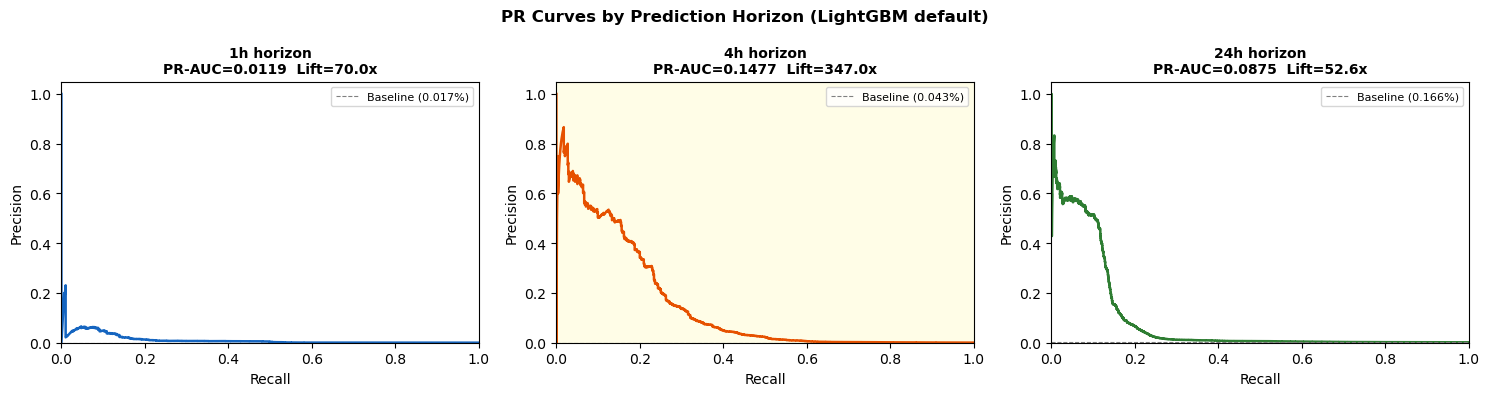

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
horizon_colors = ['#1565C0', '#E65100', '#2E7D32']

for ax, (target, res), color in zip(axes, horizon_results.items(), horizon_colors):
    prec_c, rec_c, _ = precision_recall_curve(res['y_te'], res['preds'])
    ax.plot(rec_c, prec_c, color=color, lw=1.8)
    ax.axhline(res['base'], color='grey', lw=0.8, ls='--', label=f'Baseline ({res["base"]:.3%})')
    horizon_label = target.replace('depeg_next_','').replace('_down','')
    ax.set_title(f'{horizon_label} horizon\nPR-AUC={res["pr"]:.4f}  Lift={res["lift"]:.1f}x',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(fontsize=8); ax.set_xlim(0, 1); ax.set_ylim(0, None)
    if target == best_target:
        ax.patch.set_facecolor('#FFFDE7')

fig.suptitle('PR Curves by Prediction Horizon (LightGBM default)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'nb09_horizon_pr_curves.png', dpi=130, bbox_inches='tight')
plt.show()

## Part 2 — Algorithm Comparison
Run all five algorithms on the best horizon. Default hyperparameters throughout.

In [7]:
TARGET = best_target
y_tr_a = tr[TARGET].values.astype(float)
y_te_a = te[TARGET].values.astype(float)
spw    = (1 - y_tr_a.mean()) / max(y_tr_a.mean(), 1e-9)
base   = float(y_te_a.mean())

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

ALGORITHMS = {}
ALGORITHMS['Logistic Regression'] = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42)
ALGORITHMS['Random Forest'] = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1)
if HAS_LGB:
    ALGORITHMS['LightGBM'] = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        min_child_samples=50, scale_pos_weight=spw,
        random_state=42, verbosity=-1)
if HAS_XGB:
    ALGORITHMS['XGBoost'] = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        scale_pos_weight=spw, random_state=42,
        eval_metric='aucpr', verbosity=0)
if HAS_CAT:
    ALGORITHMS['CatBoost'] = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced', random_seed=42, verbose=0)

print(f'Target: {TARGET}  |  Base rate: {base:.4%}  |  SPW: {spw:.0f}')
print(f'Algorithms: {list(ALGORITHMS.keys())}')

Target: depeg_next_4h_down  |  Base rate: 0.0426%  |  SPW: 104
Algorithms: ['Logistic Regression', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost']


In [8]:
algo_results = {}

print(f"{'Algorithm':<22} {'PR-AUC':>8} {'Lift':>8} {'ROC-AUC':>9} {'F2@1%':>8}")
print('-' * 60)

for name, model in ALGORITHMS.items():
    use_scaled = name == 'Logistic Regression'
    Xtr = X_tr_sc if use_scaled else X_tr
    Xte = X_te_sc if use_scaled else X_te

    model.fit(Xtr, y_tr_a)
    p = model.predict_proba(Xte)[:, 1]

    pr   = average_precision_score(y_te_a, p)
    roc  = roc_auc_score(y_te_a, p)
    lift = pr / base

    thresh = np.percentile(p, 99)
    alerts = p >= thresh
    tp   = int((alerts & (y_te_a == 1)).sum())
    prec = tp / alerts.sum() if alerts.sum() > 0 else 0
    rec  = tp / int(y_te_a.sum()) if y_te_a.sum() > 0 else 0
    f2   = (5 * prec * rec) / (4 * prec + rec) if (prec + rec) > 0 else 0

    algo_results[name] = dict(pr=pr, roc=roc, lift=lift, f2=f2, preds=p)
    print(f'{name:<22} {pr:>8.4f} {lift:>7.1f}x {roc:>9.4f} {f2:>8.4f}')

best_algo = max(algo_results, key=lambda a: algo_results[a]['lift'])
print(f'\n→ Best algorithm: {best_algo}  (Lift {algo_results[best_algo]["lift"]:.1f}x)')

Algorithm                PR-AUC     Lift   ROC-AUC    F2@1%
------------------------------------------------------------


Logistic Regression      0.0213    50.0x    0.5200   0.0561


Random Forest            0.1949   458.0x    0.8702   0.1080


LightGBM                 0.1477   347.0x    0.8713   0.0914


XGBoost                  0.1454   341.7x    0.8155   0.0791


CatBoost                 0.2078   488.1x    0.9063   0.1292

→ Best algorithm: CatBoost  (Lift 488.1x)


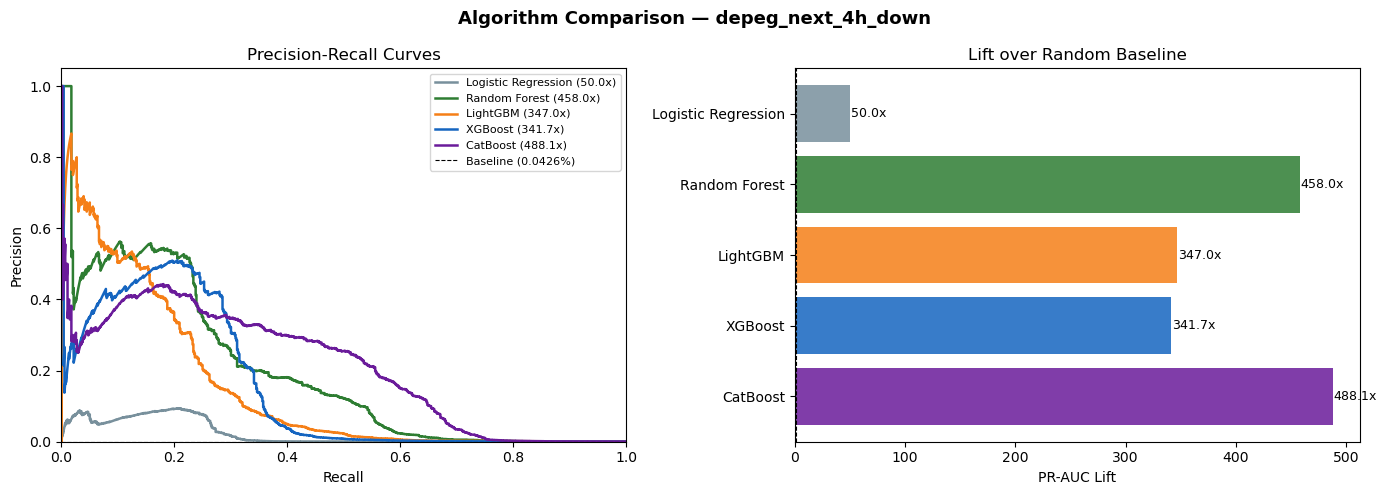

In [9]:
ALGO_COLORS = {
    'Logistic Regression': '#78909C',
    'Random Forest':       '#2E7D32',
    'LightGBM':            '#F57F17',
    'XGBoost':             '#1565C0',
    'CatBoost':            '#6A1B9A',
}

fig, (ax_pr, ax_bar) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Algorithm Comparison — {TARGET}', fontsize=13, fontweight='bold')

for name, res in algo_results.items():
    prec_c, rec_c, _ = precision_recall_curve(y_te_a, res['preds'])
    ax_pr.plot(rec_c, prec_c, label=f"{name} ({res['lift']:.1f}x)",
               color=ALGO_COLORS.get(name, 'grey'), lw=1.8)
ax_pr.axhline(base, color='black', lw=0.8, ls='--', label=f'Baseline ({base:.4%})')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves'); ax_pr.legend(fontsize=8)
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, None)

names  = list(algo_results.keys())
lifts  = [algo_results[n]['lift'] for n in names]
colors = [ALGO_COLORS.get(n, 'grey') for n in names]
bars = ax_bar.barh(names, lifts, color=colors, alpha=0.85)
for bar, v in zip(bars, lifts):
    ax_bar.text(v + 0.5, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}x', va='center', fontsize=9)
ax_bar.axvline(1, color='black', lw=0.8, ls='--')
ax_bar.set_xlabel('PR-AUC Lift'); ax_bar.set_title('Lift over Random Baseline')
ax_bar.invert_yaxis()

plt.tight_layout()
plt.savefig(FEATURES_DIR / 'nb09_algo_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## Summary

In [10]:
print('=' * 58)
print('  NB09 — Baseline Model Comparison Summary')
print('=' * 58)
print()
print('HORIZON COMPARISON (LightGBM default)')
print(f"  {'Horizon':<12} {'Base rate':>10} {'PR-AUC':>8} {'Lift':>8}")
print(f"  {'-'*42}")
for target, res in horizon_results.items():
    horizon = target.replace('depeg_next_','').replace('_down','')
    marker  = '  ← best' if target == best_target else ''
    print(f"  {horizon:<12} {res['base']:>10.4%} {res['pr']:>8.4f} {res['lift']:>7.1f}x{marker}")
print()
print(f'ALGORITHM COMPARISON (target: {best_target})')
print(f"  {'Algorithm':<22} {'PR-AUC':>8} {'Lift':>8} {'F2@1%':>8}")
print(f"  {'-'*50}")
for name, res in algo_results.items():
    marker = '  ← best' if name == best_algo else ''
    print(f"  {name:<22} {res['pr']:>8.4f} {res['lift']:>7.1f}x {res['f2']:>8.4f}{marker}")
print()
print('WINNER')
print(f"  Algorithm : {best_algo}")
print(f"  Target    : {best_target}")
print(f"  PR-AUC    : {algo_results[best_algo]['pr']:.4f}  ({algo_results[best_algo]['lift']:.1f}x lift)")
print(f"  Note      : default hyperparameters — tuned version in NB22")
print('=' * 58)

  NB09 — Baseline Model Comparison Summary

HORIZON COMPARISON (LightGBM default)
  Horizon       Base rate   PR-AUC     Lift
  ------------------------------------------
  1h              0.0171%   0.0119    70.0x
  4h              0.0426%   0.1477   347.0x  ← best
  24h             0.1663%   0.0875    52.6x

ALGORITHM COMPARISON (target: depeg_next_4h_down)
  Algorithm                PR-AUC     Lift    F2@1%
  --------------------------------------------------
  Logistic Regression      0.0213    50.0x   0.0561
  Random Forest            0.1949   458.0x   0.1080
  LightGBM                 0.1477   347.0x   0.0914
  XGBoost                  0.1454   341.7x   0.0791
  CatBoost                 0.2078   488.1x   0.1292  ← best

WINNER
  Algorithm : CatBoost
  Target    : depeg_next_4h_down
  PR-AUC    : 0.2078  (488.1x lift)
  Note      : default hyperparameters — tuned version in NB22
